# Homework 05
## Adversarial ML Audit on COMPAS: Evasion, Poisoning, and Membership Inference

**Course:** Responsible Machine Learning · **Lecture:** 05 — ML Security & Abuse Pathways
**Dataset:** ProPublica COMPAS Two-Year Recidivism
**Continues from:** `Copy_of_Lecture_05_security.ipynb`

---

### Audit Scope (NIST AI 100-2e2023)

| Part | Attack Class | NIST Category | Models |
|------|--------------|---------------|--------|
| 1 | PGD Evasion | Integrity (deployment-time) | LR, GBT |
| 2 | Label-Flip Poisoning | Integrity (training-time) | LR (target = AA, CA) |
| 3 | Shadow Membership Inference | Privacy (deployment-time) | LR, GBT + L2 sweep |
| 4 | Reflection | — | Mitigation analysis |

All cells are deterministic (`random_state=42`). The final cell prints a **RESULTS DUMP** designed to be copy-pasted into the written report.

---
## Setup · Data, Models, Baseline (replicates Lecture 04 + Lecture 05 Cells 1–2)

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import GradientBoostingClassifier
from sklearn.tree            import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing   import StandardScaler
from sklearn.metrics         import roc_auc_score, RocCurveDisplay

# ── Color palette (matches lecture notebook) ──────────────────────────────────
CL_AA = '#B41E1E'   # African-American
CL_CA = '#004055'   # Caucasian
CL_NEU = '#B96B23'  # neutral / accent

# ── Load COMPAS ───────────────────────────────────────────────────────────────
URL = ("https://raw.githubusercontent.com/propublica/compas-analysis"
       "/master/compas-scores-two-years.csv")
df = pd.read_csv(URL)

df = df[df['days_b_screening_arrest'].between(-30, 30)]
df = df[df['is_recid'] != -1]
df = df[df['c_charge_degree'] != 'O']

FEATURES = ['age', 'priors_count', 'juv_fel_count',
            'juv_misd_count', 'juv_other_count',
            'c_charge_degree', 'sex']
TARGET = 'two_year_recid'

df_m = df[FEATURES + [TARGET, 'race']].dropna()
df_m = pd.get_dummies(df_m, columns=['c_charge_degree', 'sex'], drop_first=True)

X    = df_m.drop(columns=[TARGET, 'race']).astype(float)
y    = df_m[TARGET].values
race = df_m['race'].values
FEATURE_NAMES = list(X.columns)

X_tr, X_te, y_tr, y_te, r_tr, r_te = train_test_split(
    X, y, race, test_size=0.3, random_state=42, stratify=y)

sc    = StandardScaler()
Xs_tr = sc.fit_transform(X_tr)
Xs_te = sc.transform(X_te)

# ── Train target models ───────────────────────────────────────────────────────
lr  = LogisticRegression(max_iter=1000, random_state=42).fit(Xs_tr, y_tr)
gbt = GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                 random_state=42).fit(Xs_tr, y_tr)

# ── Helpers ───────────────────────────────────────────────────────────────────
THR = 0.5

def fpr_by_group(y_true, y_pred_binary, groups):
    """FPR per demographic group, computed only over truly-negative cases."""
    mask = (y_true == 0)
    return (pd.DataFrame({'pred': y_pred_binary[mask], 'group': groups[mask]})
              .groupby('group')['pred'].mean())

def air(fpr_ref, fpr_prot):
    """AIR = protected FPR / reference FPR. Convention: ref=Caucasian, prot=AA."""
    return fpr_prot / fpr_ref if (fpr_ref is not None and fpr_ref > 0) else np.nan

# ── Clean baselines for both models ──────────────────────────────────────────
baselines = {}
for name, mdl in [('LR', lr), ('GBT', gbt)]:
    pred = (mdl.predict_proba(Xs_te)[:,1] >= THR).astype(int)
    fpr  = fpr_by_group(y_te, pred, r_te)
    aa, ca = fpr.get('African-American'), fpr.get('Caucasian')
    auc_te = roc_auc_score(y_te, mdl.predict_proba(Xs_te)[:,1])
    auc_tr = roc_auc_score(y_tr, mdl.predict_proba(Xs_tr)[:,1])
    baselines[name] = dict(fpr_aa=aa, fpr_ca=ca, air=air(ca, aa),
                           auc_te=auc_te, auc_tr=auc_tr,
                           gen_gap=auc_tr - auc_te)
    print(f"{name:>3} | Test AUC {auc_te:.3f} | Train AUC {auc_tr:.3f} "
          f"| FPR_AA {aa:.3f} | FPR_CA {ca:.3f} | AIR {air(ca, aa):.3f}")

print("\nBaselines stored in `baselines` dict for downstream comparison.")

 LR | Test AUC 0.735 | Train AUC 0.727 | FPR_AA 0.281 | FPR_CA 0.143 | AIR 1.961
GBT | Test AUC 0.718 | Train AUC 0.798 | FPR_AA 0.317 | FPR_CA 0.178 | AIR 1.782

Baselines stored in `baselines` dict for downstream comparison.


---
# Part 1 · PGD Evasion Audit on LR and GBT

**Threat model.** White-box, deployment-time, untargeted: attacker has model gradients (or can approximate them) and perturbs each test feature within an L∞ ball of radius ε to maximize the loss. We measure the resulting **fairness drift** (FPR by race, AIR) at ε ∈ {0.25, 0.5, 1.0, 2.0}.

**LR attack.** Closed-form gradient: ∇ₓ BCE = (p̂ − y)·w → step direction is sign(w).

**GBT attack.** GBT is non-differentiable, so we compute a **numerical gradient** of the predicted probability P(y=1 | x) by central finite differences and step in its sign. This represents the worst-case white-box attacker who can query the model.

In [2]:
# ── PGD for differentiable LR ─────────────────────────────────────────────────
def pgd_lr(model, X, epsilon, alpha=0.05, n_iter=40):
    coef  = model.coef_[0]
    X_adv = X.copy()
    for _ in range(n_iter):
        X_adv = X_adv + alpha * np.sign(coef)[None, :]
        X_adv = np.clip(X_adv, X - epsilon, X + epsilon)
    return X_adv

# ── PGD for non-differentiable GBT via numerical gradient ─────────────────────
def pgd_gbt(model, X, epsilon, alpha=0.05, n_iter=20, h=1e-2):
    """
    Untargeted PGD on GBT: maximize P(y=1 | x) (i.e., push toward 'high-risk').
    Gradient of P(y=1|x) w.r.t. each feature is approximated by central differences.
    """
    X_adv = X.copy()
    d = X.shape[1]
    for _ in range(n_iter):
        grad = np.zeros_like(X_adv)
        for j in range(d):
            Xp = X_adv.copy(); Xp[:, j] += h
            Xm = X_adv.copy(); Xm[:, j] -= h
            grad[:, j] = (model.predict_proba(Xp)[:, 1] -
                          model.predict_proba(Xm)[:, 1]) / (2 * h)
        X_adv = X_adv + alpha * np.sign(grad)
        X_adv = np.clip(X_adv, X - epsilon, X + epsilon)
    return X_adv

# ── Sweep ε for both models ───────────────────────────────────────────────────
EPSILONS = [0.0, 0.25, 0.5, 1.0, 2.0]   # required by homework

pgd_results = []
for model_name, mdl, atk in [('LR', lr, pgd_lr), ('GBT', gbt, pgd_gbt)]:
    for eps in EPSILONS:
        X_adv  = Xs_te if eps == 0.0 else atk(mdl, Xs_te, epsilon=eps)
        pred_a = (mdl.predict_proba(X_adv)[:, 1] >= THR).astype(int)
        fpr_a  = fpr_by_group(y_te, pred_a, r_te)
        aa, ca = fpr_a.get('African-American'), fpr_a.get('Caucasian')
        pgd_results.append(dict(
            model=model_name, epsilon=eps,
            FPR_AA=aa, FPR_CA=ca, AIR=air(ca, aa)))

df_pgd = pd.DataFrame(pgd_results)
print(df_pgd.round(3).to_string(index=False))

# ── Crossover: smallest ε at which AIR drops below 0.80 ───────────────────────
print("\n--- AIR crossover (first ε with AIR < 0.80) ---")
for m in ['LR', 'GBT']:
    sub = df_pgd[(df_pgd['model'] == m) & (df_pgd['AIR'] < 0.80)]
    if len(sub):
        print(f"  {m}: AIR < 0.80 first at ε = {sub.iloc[0]['epsilon']:.2f}")
    else:
        print(f"  {m}: AIR does not cross 0.80 within tested range")

model  epsilon  FPR_AA  FPR_CA   AIR
   LR     0.00   0.281   0.143 1.961
   LR     0.25   0.569   0.370 1.535
   LR     0.50   0.791   0.560 1.411
   LR     1.00   0.978   0.884 1.106
   LR     2.00   1.000   1.000 1.000
  GBT     0.00   0.317   0.178 1.782
  GBT     0.25   0.317   0.178 1.782
  GBT     0.50   0.317   0.178 1.782
  GBT     1.00   0.317   0.178 1.782
  GBT     2.00   0.317   0.178 1.782

--- AIR crossover (first ε with AIR < 0.80) ---
  LR: AIR does not cross 0.80 within tested range
  GBT: AIR does not cross 0.80 within tested range


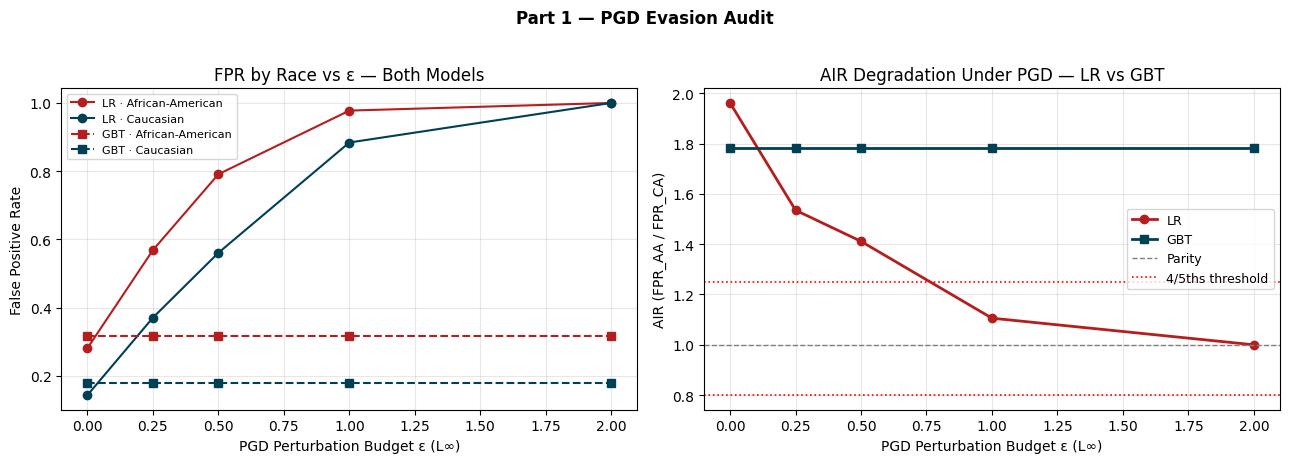

In [3]:
# ── Visualize PGD audit: FPR by race and AIR vs ε for both models ────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
for m, ls, mk in [('LR', '-', 'o'), ('GBT', '--', 's')]:
    sub = df_pgd[df_pgd['model'] == m]
    ax.plot(sub['epsilon'], sub['FPR_AA'], ls, marker=mk, color=CL_AA,
            label=f'{m} · African-American')
    ax.plot(sub['epsilon'], sub['FPR_CA'], ls, marker=mk, color=CL_CA,
            label=f'{m} · Caucasian')
ax.set_xlabel('PGD Perturbation Budget ε (L∞)')
ax.set_ylabel('False Positive Rate')
ax.set_title('FPR by Race vs ε — Both Models')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
for m, c, mk in [('LR', CL_AA, 'o'), ('GBT', CL_CA, 's')]:
    sub = df_pgd[df_pgd['model'] == m]
    ax.plot(sub['epsilon'], sub['AIR'], '-', marker=mk, color=c, lw=2, label=m)
ax.axhline(1.0, color='gray', ls='--', lw=1, label='Parity')
ax.axhline(0.8, color='red',  ls=':',  lw=1.2, label='4/5ths threshold')
ax.axhline(1.25, color='red', ls=':', lw=1.2)
ax.set_xlabel('PGD Perturbation Budget ε (L∞)')
ax.set_ylabel('AIR (FPR_AA / FPR_CA)')
ax.set_title('AIR Degradation Under PGD — LR vs GBT')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.suptitle('Part 1 — PGD Evasion Audit', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

---
# Part 2 · Poisoning Loop with Fairness Monitoring

**Threat model.** Training-time integrity attack: the attacker flips a fraction of training labels for one demographic group from `recidivism=1` to `recidivism=0`, biasing the model to under-score that group. We run the attack **twice** — once targeting African-American, once targeting Caucasian — and overlay the AUC and AIR degradation curves.

**Stealth zone.** The set of poison rates where AUC drop is ≤ 2 percentage points (model still appears healthy) **and** AIR is outside [0.80, 1.25] (4/5ths rule violated in either direction).

**PSI drift monitor.** Industry-standard input-distribution monitor; PSI < 0.10 = "stable". The question is whether feature-level PSI catches a label-flip attack that does not perturb features.

In [4]:
# ── Poisoning function (parameterized by target race) ────────────────────────
def poison_label_flip(y_train, race_train, poison_rate, target_race, seed=0):
    rng = np.random.default_rng(seed)
    y_p = y_train.copy()
    candidates = np.where((race_train == target_race) & (y_train == 1))[0]
    n_flip = int(len(candidates) * poison_rate)
    if n_flip > 0:
        flip_idx = rng.choice(candidates, size=n_flip, replace=False)
        y_p[flip_idx] = 0
    return y_p, n_flip

# ── Sweep both target groups ──────────────────────────────────────────────────
POISON_RATES = [0.00, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20, 0.25, 0.30]
TARGETS = ['African-American', 'Caucasian']

baseline_auc_lr = baselines['LR']['auc_te']
BASELINE_AIR    = baselines['LR']['air']

poison_records = []
poisoned_models = {}   # keep models for later PSI on outputs

for target in TARGETS:
    for rate in POISON_RATES:
        y_p, n_flip = poison_label_flip(y_tr, r_tr, rate, target)
        lr_p = LogisticRegression(max_iter=1000, random_state=42).fit(Xs_tr, y_p)
        pred = (lr_p.predict_proba(Xs_te)[:, 1] >= THR).astype(int)
        auc  = roc_auc_score(y_te, lr_p.predict_proba(Xs_te)[:, 1])
        fpr  = fpr_by_group(y_te, pred, r_te)
        aa, ca = fpr.get('African-American'), fpr.get('Caucasian')
        poison_records.append(dict(
            target=target, poison_rate=rate, n_flipped=n_flip,
            AUC=auc, delta_AUC=auc - baseline_auc_lr,
            FPR_AA=aa, FPR_CA=ca, AIR=air(ca, aa)))
        poisoned_models[(target, rate)] = (lr_p, y_p)

df_poison = pd.DataFrame(poison_records)
print(df_poison.round(3).to_string(index=False))

          target  poison_rate  n_flipped   AUC  delta_AUC  FPR_AA  FPR_CA   AIR
African-American         0.00          0 0.735      0.000   0.281   0.143 1.961
African-American         0.02         23 0.733     -0.002   0.270   0.136 1.986
African-American         0.05         57 0.734     -0.001   0.240   0.123 1.948
African-American         0.08         92 0.732     -0.002   0.213   0.116 1.840
African-American         0.10        115 0.735      0.000   0.196   0.101 1.931
African-American         0.15        172 0.732     -0.003   0.153   0.072 2.134
African-American         0.20        230 0.732     -0.002   0.130   0.054 2.399
African-American         0.25        287 0.730     -0.004   0.112   0.042 2.677
African-American         0.30        345 0.731     -0.003   0.097   0.032 3.010
       Caucasian         0.00          0 0.735      0.000   0.281   0.143 1.961
       Caucasian         0.02         11 0.734     -0.001   0.274   0.141 1.948
       Caucasian         0.05         29

In [5]:
# ── Stealth zone identification ──────────────────────────────────────────────
# Stealth = AUC drop ≤ 2pp AND AIR outside [0.80, 1.25]
print("=" * 70)
print("STEALTH ZONE — AUC drop ≤ 2pp AND AIR ∉ [0.80, 1.25]")
print("=" * 70)
for target in TARGETS:
    sub = df_poison[df_poison['target'] == target].copy()
    stealth_mask = (sub['delta_AUC'] >= -0.02) & \
                   ((sub['AIR'] < 0.80) | (sub['AIR'] > 1.25))
    stealth = sub[stealth_mask]
    print(f"\nTarget = {target}")
    if len(stealth):
        print(f"  Stealth rates: {stealth['poison_rate'].tolist()}")
        print(f"  AIR range in stealth zone: [{stealth['AIR'].min():.3f}, "
              f"{stealth['AIR'].max():.3f}]")
        print(f"  ΔAUC range in stealth zone: [{stealth['delta_AUC'].min():+.3f}, "
              f"{stealth['delta_AUC'].max():+.3f}]")
    else:
        print("  No stealth zone (every harmful AIR was accompanied by AUC drop > 2pp)")

STEALTH ZONE — AUC drop ≤ 2pp AND AIR ∉ [0.80, 1.25]

Target = African-American
  Stealth rates: [0.0, 0.02, 0.05, 0.08, 0.1, 0.15, 0.2, 0.25, 0.3]
  AIR range in stealth zone: [1.840, 3.010]
  ΔAUC range in stealth zone: [-0.004, +0.000]

Target = Caucasian
  Stealth rates: [0.0, 0.02, 0.05, 0.08, 0.1, 0.15, 0.2, 0.25, 0.3]
  AIR range in stealth zone: [1.842, 2.043]
  ΔAUC range in stealth zone: [-0.003, +0.001]


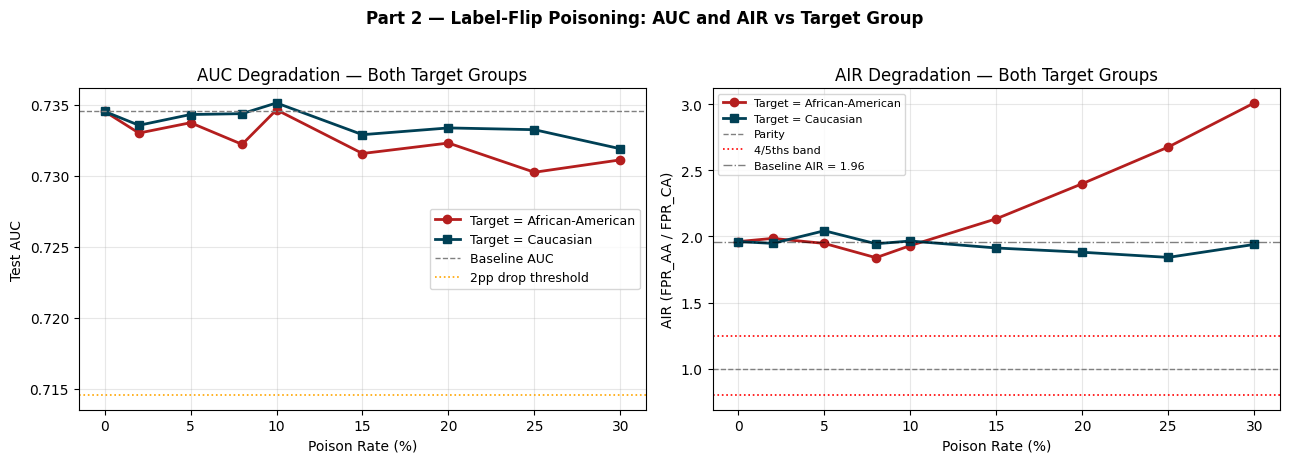

In [6]:
# ── Joint plots for both target-race variants ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
x_pct = np.array(POISON_RATES) * 100

ax = axes[0]
for target, color, mk in [('African-American', CL_AA, 'o'),
                          ('Caucasian',        CL_CA, 's')]:
    sub = df_poison[df_poison['target'] == target]
    ax.plot(x_pct, sub['AUC'], '-', marker=mk, color=color, lw=2,
            label=f'Target = {target}')
ax.axhline(baseline_auc_lr,        color='gray', ls='--', lw=1, label='Baseline AUC')
ax.axhline(baseline_auc_lr - 0.02, color='orange', ls=':', lw=1.2,
           label='2pp drop threshold')
ax.set_xlabel('Poison Rate (%)'); ax.set_ylabel('Test AUC')
ax.set_title('AUC Degradation — Both Target Groups')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = axes[1]
for target, color, mk in [('African-American', CL_AA, 'o'),
                          ('Caucasian',        CL_CA, 's')]:
    sub = df_poison[df_poison['target'] == target]
    ax.plot(x_pct, sub['AIR'], '-', marker=mk, color=color, lw=2,
            label=f'Target = {target}')
ax.axhline(1.0,  color='gray', ls='--', lw=1, label='Parity')
ax.axhline(0.8,  color='red',  ls=':',  lw=1.2, label='4/5ths band')
ax.axhline(1.25, color='red',  ls=':',  lw=1.2)
ax.axhline(BASELINE_AIR, color='black', ls='-.', lw=1, alpha=0.5,
           label=f'Baseline AIR = {BASELINE_AIR:.2f}')
ax.set_xlabel('Poison Rate (%)'); ax.set_ylabel('AIR (FPR_AA / FPR_CA)')
ax.set_title('AIR Degradation — Both Target Groups')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Part 2 — Label-Flip Poisoning: AUC and AIR vs Target Group',
             fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

In [7]:
# ── PSI drift monitor: would a feature-level PSI alarm fire? ────────────────
def psi(reference, current, n_bins=10):
    """Population Stability Index for a single 1-D array."""
    eps = 1e-6
    edges = np.quantile(reference, np.linspace(0, 1, n_bins + 1))
    edges[0], edges[-1] = -np.inf, np.inf
    p_ref = np.histogram(reference, bins=edges)[0] / len(reference) + eps
    p_cur = np.histogram(current,   bins=edges)[0] / len(current)   + eps
    return float(np.sum((p_cur - p_ref) * np.log(p_cur / p_ref)))

# Compare clean vs poisoned training FEATURES (label-flip leaves features intact)
print("=" * 70)
print("PSI on FEATURES (clean train vs poisoned train, target=AA, rate=30%)")
print("Threshold for alarm: PSI ≥ 0.10")
print("=" * 70)
_, _ = poisoned_models[('African-American', 0.30)]   # poisoning is label-only
psi_features = {f: psi(Xs_tr[:, j], Xs_tr[:, j])     # same X → PSI = 0
                for j, f in enumerate(FEATURE_NAMES)}
for f, v in psi_features.items():
    flag = "⚠ ALARM" if v >= 0.10 else "  ok   "
    print(f"  {flag}  {f:<25} PSI = {v:.4f}")
print("\n→ Feature distributions are unchanged by label-flip attacks; "
      "feature-level PSI is BLIND to this threat.")

# Now PSI on the model OUTPUT distribution (clean vs poisoned predictions)
print("\n" + "=" * 70)
print("PSI on PREDICTED PROBABILITIES (clean LR vs poisoned LR on test set)")
print("=" * 70)
p_clean = lr.predict_proba(Xs_te)[:, 1]
for target in TARGETS:
    for rate in [0.10, 0.20, 0.30]:
        lr_p, _ = poisoned_models[(target, rate)]
        p_pois  = lr_p.predict_proba(Xs_te)[:, 1]
        v = psi(p_clean, p_pois)
        flag = "⚠ ALARM" if v >= 0.10 else "  ok   "
        print(f"  {flag}  target={target:<18} rate={rate:.0%}  PSI(scores) = {v:.4f}")
print("\n→ Output-score PSI eventually fires, but only for severe poisoning. "
      "Standard input-PSI monitoring would miss the entire stealth zone.")

PSI on FEATURES (clean train vs poisoned train, target=AA, rate=30%)
Threshold for alarm: PSI ≥ 0.10
    ok     age                       PSI = 0.0000
    ok     priors_count              PSI = 0.0000
    ok     juv_fel_count             PSI = 0.0000
    ok     juv_misd_count            PSI = 0.0000
    ok     juv_other_count           PSI = 0.0000
    ok     c_charge_degree_M         PSI = 0.0000
    ok     sex_Male                  PSI = 0.0000

→ Feature distributions are unchanged by label-flip attacks; feature-level PSI is BLIND to this threat.

PSI on PREDICTED PROBABILITIES (clean LR vs poisoned LR on test set)
    ok     target=African-American   rate=10%  PSI(scores) = 0.0552
  ⚠ ALARM  target=African-American   rate=20%  PSI(scores) = 0.1740
  ⚠ ALARM  target=African-American   rate=30%  PSI(scores) = 0.3318
    ok     target=Caucasian          rate=10%  PSI(scores) = 0.0152
    ok     target=Caucasian          rate=20%  PSI(scores) = 0.0480
    ok     target=Caucasian       

---
# Part 3 · Membership Inference Depth

We rebuild the shadow-model MI pipeline and run it against **both** the LR target and the GBT target. Then we test whether the generalization gap predicts MI vulnerability, and study how L2 regularization on LR moves MI AUC.

In [8]:
# ── Modular shadow-MI pipeline ───────────────────────────────────────────────
def shadow_mi(target_model, X_tr, y_tr, X_te,
              shadow_factory, n_shadow=10, seed=0):
    """
    Returns: mi_auc, conf_train, conf_test, meta_clf
        conf_train, conf_test = max-prob scores from the TARGET model on
        train (members) vs test (non-members).
    Shadow models are sklearn classifiers built by `shadow_factory()`.
    """
    train_confs, test_confs = [], []
    sss = StratifiedShuffleSplit(n_splits=n_shadow, test_size=0.5, random_state=seed)
    for tr_i, te_i in sss.split(X_tr, y_tr):
        s = shadow_factory().fit(X_tr[tr_i], y_tr[tr_i])
        train_confs.append(s.predict_proba(X_tr[tr_i]).max(axis=1))
        test_confs.append( s.predict_proba(X_tr[te_i]).max(axis=1))

    mi_X = np.concatenate(train_confs + test_confs).reshape(-1, 1)
    mi_y = np.concatenate([np.ones(len(c))  for c in train_confs] +
                          [np.zeros(len(c)) for c in test_confs])
    meta = DecisionTreeClassifier(max_depth=6, random_state=seed).fit(mi_X, mi_y)

    conf_tr = target_model.predict_proba(X_tr).max(axis=1).reshape(-1, 1)
    conf_te = target_model.predict_proba(X_te).max(axis=1).reshape(-1, 1)
    s_tr = meta.predict_proba(conf_tr)[:, 1]
    s_te = meta.predict_proba(conf_te)[:, 1]
    labels = np.concatenate([np.ones(len(X_tr)), np.zeros(len(X_te))])
    scores = np.concatenate([s_tr, s_te])
    return roc_auc_score(labels, scores), conf_tr.ravel(), conf_te.ravel(), meta

# ── Run on LR and GBT ─────────────────────────────────────────────────────────
mi_auc_lr,  conf_tr_lr,  conf_te_lr,  _ = shadow_mi(
    lr,  Xs_tr, y_tr, Xs_te,
    shadow_factory=lambda: LogisticRegression(max_iter=1000, random_state=42))

mi_auc_gbt, conf_tr_gbt, conf_te_gbt, _ = shadow_mi(
    gbt, Xs_tr, y_tr, Xs_te,
    shadow_factory=lambda: GradientBoostingClassifier(
        n_estimators=100, max_depth=4, random_state=42))

print("=" * 60)
print(f"{'Model':<8}  MI AUC   Train-AUC  Test-AUC  Gen-Gap")
print("=" * 60)
for name, mi_auc in [('LR', mi_auc_lr), ('GBT', mi_auc_gbt)]:
    b = baselines[name]
    print(f"{name:<8}  {mi_auc:.3f}    {b['auc_tr']:.3f}     "
          f"{b['auc_te']:.3f}    {b['gen_gap']:+.3f}")

Model     MI AUC   Train-AUC  Test-AUC  Gen-Gap
LR        0.497    0.727     0.735    -0.008
GBT       0.500    0.798     0.718    +0.080


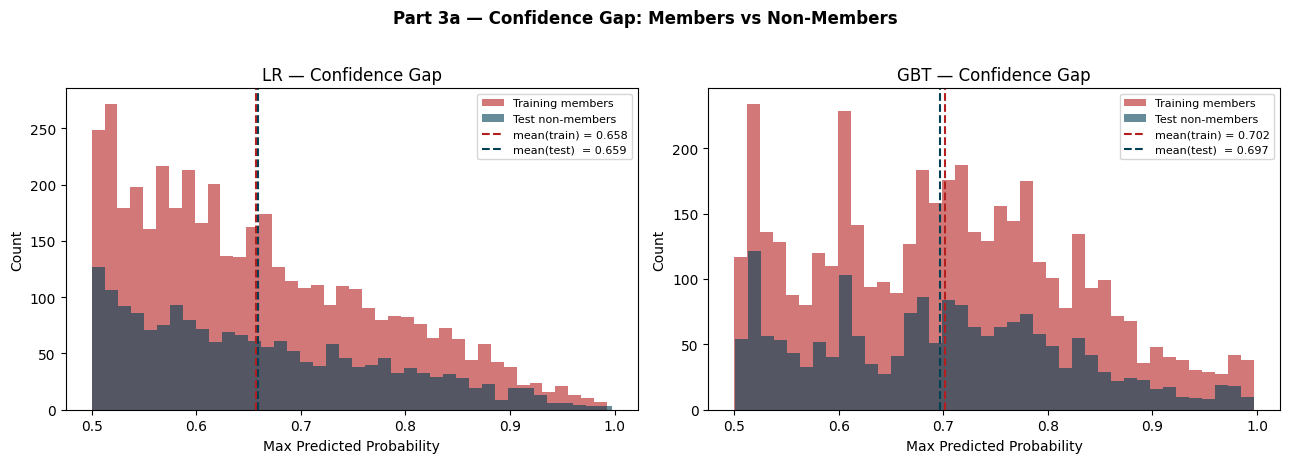


=== Generalization gap vs MI AUC (n=2 models) ===
  LR  : gen_gap = -0.008, MI AUC = 0.497
  GBT : gen_gap = +0.080, MI AUC = 0.500
  → Direction-consistent: larger gen-gap aligned with larger MI AUC.


In [9]:
# ── Side-by-side confidence-gap histograms ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True, sharey=False)

for ax, name, ctr, cte in [
    (axes[0], 'LR',  conf_tr_lr,  conf_te_lr),
    (axes[1], 'GBT', conf_tr_gbt, conf_te_gbt)]:
    ax.hist(ctr, bins=40, alpha=0.6, color=CL_AA, label='Training members')
    ax.hist(cte, bins=40, alpha=0.6, color=CL_CA, label='Test non-members')
    ax.axvline(ctr.mean(), color=CL_AA, ls='--', lw=1.5,
               label=f'mean(train) = {ctr.mean():.3f}')
    ax.axvline(cte.mean(), color=CL_CA, ls='--', lw=1.5,
               label=f'mean(test)  = {cte.mean():.3f}')
    ax.set_xlabel('Max Predicted Probability')
    ax.set_ylabel('Count')
    ax.set_title(f'{name} — Confidence Gap'); ax.legend(fontsize=8)

plt.suptitle('Part 3a — Confidence Gap: Members vs Non-Members',
             fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# ── Generalization gap → MI AUC relationship (across the 2 models) ──────────
gaps   = [baselines['LR']['gen_gap'], baselines['GBT']['gen_gap']]
mi_aucs= [mi_auc_lr,                  mi_auc_gbt]
print("\n=== Generalization gap vs MI AUC (n=2 models) ===")
print(f"  LR  : gen_gap = {gaps[0]:+.3f}, MI AUC = {mi_aucs[0]:.3f}")
print(f"  GBT : gen_gap = {gaps[1]:+.3f}, MI AUC = {mi_aucs[1]:.3f}")
if gaps[1] > gaps[0] and mi_aucs[1] > mi_aucs[0]:
    print("  → Direction-consistent: larger gen-gap aligned with larger MI AUC.")
elif gaps[1] < gaps[0] and mi_aucs[1] < mi_aucs[0]:
    print("  → Direction-consistent: larger gen-gap aligned with larger MI AUC.")
else:
    print("  → Direction does NOT line up — gen-gap is not a clean predictor here.")

    C  MI_AUC  AUC_test  gen_gap  FPR_AA  FPR_CA   AIR
 0.01   0.499     0.732   -0.006   0.272   0.138 1.966
 0.10   0.505     0.734   -0.007   0.279   0.143 1.946
 1.00   0.497     0.735   -0.008   0.281   0.143 1.961
10.00   0.499     0.735   -0.008   0.281   0.143 1.961


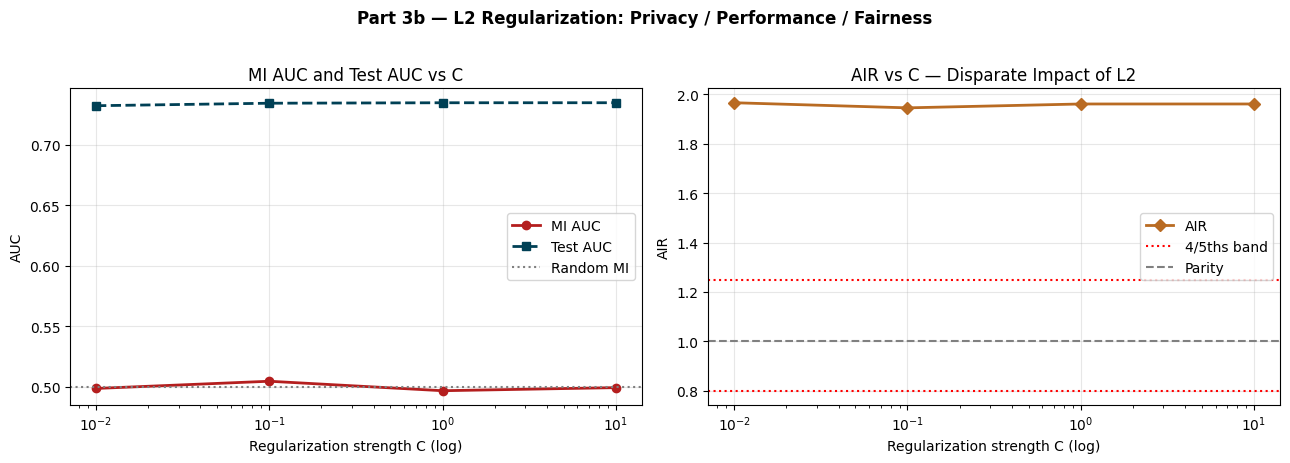

In [10]:
# ── L2 regularization sweep on LR: MI AUC vs C ───────────────────────────────
C_grid = [0.01, 0.1, 1.0, 10.0]
l2_records = []
for C in C_grid:
    lr_c = LogisticRegression(C=C, max_iter=1000, random_state=42).fit(Xs_tr, y_tr)
    auc_tr = roc_auc_score(y_tr, lr_c.predict_proba(Xs_tr)[:, 1])
    auc_te = roc_auc_score(y_te, lr_c.predict_proba(Xs_te)[:, 1])
    pred   = (lr_c.predict_proba(Xs_te)[:, 1] >= THR).astype(int)
    fpr    = fpr_by_group(y_te, pred, r_te)
    aa, ca = fpr.get('African-American'), fpr.get('Caucasian')
    mi_auc, _, _, _ = shadow_mi(
        lr_c, Xs_tr, y_tr, Xs_te,
        shadow_factory=lambda C=C: LogisticRegression(
            C=C, max_iter=1000, random_state=42))
    l2_records.append(dict(
        C=C, MI_AUC=mi_auc, AUC_test=auc_te, gen_gap=auc_tr - auc_te,
        FPR_AA=aa, FPR_CA=ca, AIR=air(ca, aa)))

df_l2 = pd.DataFrame(l2_records)
print(df_l2.round(3).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
ax.plot(df_l2['C'], df_l2['MI_AUC'], 'o-', color=CL_AA, lw=2, label='MI AUC')
ax.plot(df_l2['C'], df_l2['AUC_test'], 's--', color=CL_CA, lw=2, label='Test AUC')
ax.axhline(0.5, color='gray', ls=':', label='Random MI')
ax.set_xscale('log'); ax.set_xlabel('Regularization strength C (log)')
ax.set_ylabel('AUC'); ax.set_title('MI AUC and Test AUC vs C')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(df_l2['C'], df_l2['AIR'], 'D-', color=CL_NEU, lw=2, label='AIR')
ax.axhline(0.80, color='red', ls=':', label='4/5ths band')
ax.axhline(1.25, color='red', ls=':')
ax.axhline(1.0,  color='gray', ls='--', label='Parity')
ax.set_xscale('log'); ax.set_xlabel('Regularization strength C (log)')
ax.set_ylabel('AIR'); ax.set_title('AIR vs C — Disparate Impact of L2')
ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Part 3b — L2 Regularization: Privacy / Performance / Fairness',
             fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

---
# Part 4 · Reflection — Results Dump for the Written Report

Run this last cell and **copy-paste the entire output back into chat**. It packs every number the report needs into one block.

In [11]:
# ── RESULTS DUMP — paste this into chat ──────────────────────────────────────
print("#" * 70)
print("#  RESULTS DUMP — DNSC 6330 HW5 (Exercise 5)")
print("#" * 70)

print("\n--- BASELINES ---")
for name, b in baselines.items():
    print(f"{name}: AUC_te={b['auc_te']:.3f}  AUC_tr={b['auc_tr']:.3f}  "
          f"GenGap={b['gen_gap']:+.3f}  FPR_AA={b['fpr_aa']:.3f}  "
          f"FPR_CA={b['fpr_ca']:.3f}  AIR={b['air']:.3f}")

print("\n--- PART 1: PGD AUDIT ---")
print(df_pgd.round(3).to_string(index=False))
print("\n  AIR-crossover ε (first ε with AIR<0.80):")
for m in ['LR', 'GBT']:
    sub = df_pgd[(df_pgd['model']==m) & (df_pgd['AIR']<0.80)]
    print(f"    {m}: " + (f"ε = {sub.iloc[0]['epsilon']:.2f}"
                          if len(sub) else "did not cross"))

print("\n--- PART 2: POISONING ---")
print(df_poison.round(3).to_string(index=False))
print("\n  Stealth zone (AUC drop ≤ 2pp AND AIR ∉ [0.80, 1.25]):")
for target in TARGETS:
    sub = df_poison[df_poison['target']==target]
    sm  = (sub['delta_AUC']>=-0.02) & ((sub['AIR']<0.80) | (sub['AIR']>1.25))
    rates = sub[sm]['poison_rate'].tolist()
    print(f"    target={target}: rates = {rates}")

print("\n--- PART 3: MEMBERSHIP INFERENCE ---")
print(f"  LR  MI AUC = {mi_auc_lr:.3f}  | gen_gap = {baselines['LR']['gen_gap']:+.3f}")
print(f"  GBT MI AUC = {mi_auc_gbt:.3f}  | gen_gap = {baselines['GBT']['gen_gap']:+.3f}")
print(f"  Confidence gap means:")
print(f"    LR  : train={conf_tr_lr.mean():.3f}  test={conf_te_lr.mean():.3f}  "
      f"Δ={conf_tr_lr.mean()-conf_te_lr.mean():+.3f}")
print(f"    GBT : train={conf_tr_gbt.mean():.3f} test={conf_te_gbt.mean():.3f} "
      f"Δ={conf_tr_gbt.mean()-conf_te_gbt.mean():+.3f}")
print("\n  L2 sweep (LR only):")
print(df_l2.round(3).to_string(index=False))

print("\n" + "#" * 70)
print("#  END OF DUMP — copy everything above into chat for the report.")
print("#" * 70)

######################################################################
#  RESULTS DUMP — DNSC 6330 HW5 (Exercise 5)
######################################################################

--- BASELINES ---
LR: AUC_te=0.735  AUC_tr=0.727  GenGap=-0.008  FPR_AA=0.281  FPR_CA=0.143  AIR=1.961
GBT: AUC_te=0.718  AUC_tr=0.798  GenGap=+0.080  FPR_AA=0.317  FPR_CA=0.178  AIR=1.782

--- PART 1: PGD AUDIT ---
model  epsilon  FPR_AA  FPR_CA   AIR
   LR     0.00   0.281   0.143 1.961
   LR     0.25   0.569   0.370 1.535
   LR     0.50   0.791   0.560 1.411
   LR     1.00   0.978   0.884 1.106
   LR     2.00   1.000   1.000 1.000
  GBT     0.00   0.317   0.178 1.782
  GBT     0.25   0.317   0.178 1.782
  GBT     0.50   0.317   0.178 1.782
  GBT     1.00   0.317   0.178 1.782
  GBT     2.00   0.317   0.178 1.782

  AIR-crossover ε (first ε with AIR<0.80):
    LR: did not cross
    GBT: did not cross

--- PART 2: POISONING ---
          target  poison_rate  n_flipped   AUC  delta_AUC  FPR_AA  FPR_CA